In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("Data Exploration for Baseline Models")
print("=" * 40)

Data Exploration for Baseline Models


In [2]:
print("📊 LOADING DATA QUALITY REPORT")
print("-" * 30)

with open('../data/processed/data_quality_report.json', 'r') as f:
    quality_report = json.load(f)

print("Quality Report Contents:")
for key, value in quality_report.items():
    print(f"  {key}: {value}")

📊 LOADING DATA QUALITY REPORT
------------------------------
Quality Report Contents:
  dataset_info: {'total_samples': 7029, 'smiles_column': 'processed_smiles', 'target_column': 'FFV', 'split_ratios': [0.7, 0.15, 0.15], 'random_state': 42}
  quality_metrics: {'target_stats': {'count': 7029, 'mean': 0.3672059548207427, 'std': 0.02960444690432215, 'min': 0.2269924, 'max': 0.77709707, 'q25': 0.34954591, 'q50': 0.36425728, 'q75': 0.38077316}, 'smiles_stats': {'avg_length': 57.52098449281548, 'min_length': 2, 'max_length': 302, 'std_length': 33.368248028510855}, 'molecular_stats': {'valid_smiles_count': 7029, 'valid_smiles_percentage': 100.0, 'molecular_weight': {'mean': 459.93067897984815, 'std': 241.58901271584972, 'min': 28.053999999999995, 'max': 2204.4979999999987}, 'num_atoms': {'mean': 33.49324228197467, 'std': 18.078364883313743, 'min': 2.0, 'max': 164.0}, 'num_bonds': {'mean': 36.416133162612034, 'std': 20.802432261799048, 'min': 1.0, 'max': 179.0}}, 'outliers': {'count': 269, 'p

In [3]:
print("\n🧪 FFV DATASET ANALYSIS")
print("-" * 25)

ffv_df = pd.read_csv('../data/processed/filtered_ffv_dataset.csv')
print(f"Dataset shape: {ffv_df.shape}")
print(f"Columns: {list(ffv_df.columns)}")
print(f"Memory usage: {ffv_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Show first few rows
print("\nFirst 5 rows:")
display(ffv_df.head())


🧪 FFV DATASET ANALYSIS
-------------------------
Dataset shape: (7029, 8)
Columns: ['id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg', 'processed_smiles']
Memory usage: 1.9 MB

First 5 rows:


,id,SMILES,Tg,FFV,Tc,Density,Rg,processed_smiles
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN,CCc1ccccc1C(=O)OCCCCCC
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN,Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5c...
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN,Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(S...
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN,Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N)c(...
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN,Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N+...


In [4]:
print("\n🔍 FFV DATA QUALITY")
print("-" * 20)

# Check for missing values
print("Missing values per column:")
missing_counts = ffv_df.isnull().sum()
for col, count in missing_counts.items():
    if count > 0:
        print(f"  {col}: {count} ({count/len(ffv_df)*100:.1f}%)")

# Check FFV distribution
if 'FFV' in ffv_df.columns:
    ffv_values = ffv_df['FFV'].dropna()
    print(f"\nFFV Statistics:")
    print(f"  Count: {len(ffv_values)}")
    print(f"  Mean: {ffv_values.mean():.4f}")
    print(f"  Std: {ffv_values.std():.4f}")
    print(f"  Min: {ffv_values.min():.4f}")
    print(f"  Max: {ffv_values.max():.4f}")
    print(f"  Range: {ffv_values.max() - ffv_values.min():.4f}")


🔍 FFV DATA QUALITY
--------------------
Missing values per column:
  Tg: 7029 (100.0%)
  Tc: 6729 (95.7%)
  Density: 6760 (96.2%)
  Rg: 6760 (96.2%)

FFV Statistics:
  Count: 7029
  Mean: 0.3672
  Std: 0.0296
  Min: 0.2270
  Max: 0.7771
  Range: 0.5501


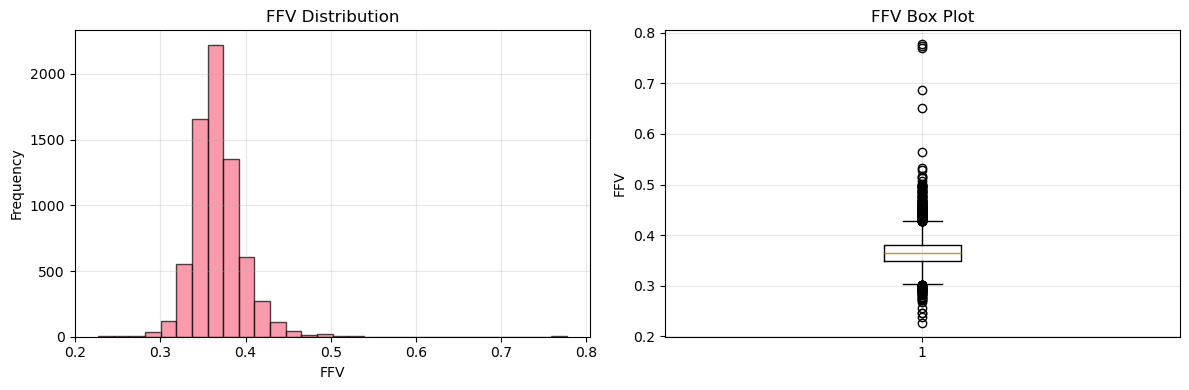

In [5]:
if 'FFV' in ffv_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    axes[0].hist(ffv_df['FFV'].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('FFV')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('FFV Distribution')
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    axes[1].boxplot(ffv_df['FFV'].dropna())
    axes[1].set_ylabel('FFV')
    axes[1].set_title('FFV Box Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [6]:
print("\n🌡️  TG DATASET ANALYSIS")
print("-" * 25)

tg_df = pd.read_csv('../data/processed/filtered_tg_dataset.csv')
print(f"Dataset shape: {tg_df.shape}")
print(f"Columns: {list(tg_df.columns)}")
print(f"Memory usage: {tg_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Show first few rows
print("\nFirst 5 rows:")
display(tg_df.head())



🌡️  TG DATASET ANALYSIS
-------------------------
Dataset shape: (510, 8)
Columns: ['id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg', 'processed_smiles']
Memory usage: 0.1 MB

First 5 rows:


,id,SMILES,Tg,FFV,Tc,Density,Rg,processed_smiles
0,10142210,*NC(C)C(=O)NCC(=O)NCC(*)=O,208.639749,NaN,NaN,NaN,NaN,NC(C)C(=O)NCC(=O)NCC=O
1,13838538,*CCCCCCSSCCCCSS*,-41.266724,NaN,0.192,NaN,NaN,CCCCCCSSCCCCSS
2,16498242,*C=CCCCCCCCC*,-17.282022,NaN,NaN,NaN,NaN,C=CCCCCCCCC
3,30582999,*CCCCCCCCCCOC(=O)c1ccc(C(=O)NCCNC(=O)c2ccc(C(=...,4.250403,NaN,NaN,NaN,NaN,CCCCCCCCCCOC(=O)c1ccc(C(=O)NCCNC(=O)c2ccc(C(=O...
4,36217683,*c1nc2cc3sc(-c4cc(OCCCCCC)c(*)cc4OCCCCCC)nc3cc2s1,168.526313,NaN,NaN,NaN,NaN,c1nc2cc3sc(-c4cc(OCCCCCC)ccc4OCCCCCC)nc3cc2s1


In [7]:
print("\n🔍 TG DATA QUALITY")
print("-" * 20)

# Check for missing values
print("Missing values per column:")
missing_counts = tg_df.isnull().sum()
for col, count in missing_counts.items():
    if count > 0:
        print(f"  {col}: {count} ({count/len(tg_df)*100:.1f}%)")

# Check Tg distribution
if 'Tg' in tg_df.columns:
    tg_values = tg_df['Tg'].dropna()
    print(f"\nTg Statistics:")
    print(f"  Count: {len(tg_values)}")
    print(f"  Mean: {tg_values.mean():.2f}")
    print(f"  Std: {tg_values.std():.2f}")
    print(f"  Min: {tg_values.min():.2f}")
    print(f"  Max: {tg_values.max():.2f}")
    print(f"  Range: {tg_values.max() - tg_values.min():.2f}")



🔍 TG DATA QUALITY
--------------------
Missing values per column:
  FFV: 510 (100.0%)
  Tc: 478 (93.7%)
  Density: 487 (95.5%)
  Rg: 487 (95.5%)

Tg Statistics:
  Count: 510
  Mean: 96.65
  Std: 111.25
  Min: -148.03
  Max: 472.25
  Range: 620.28


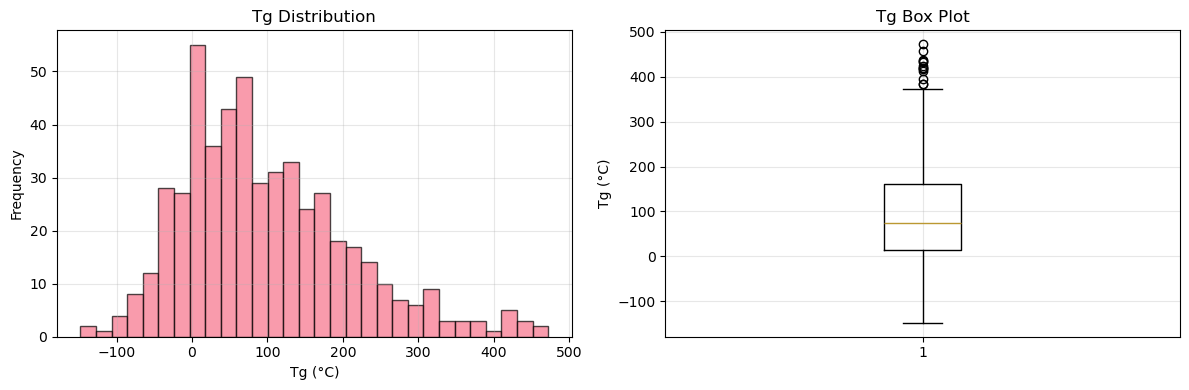

In [8]:
if 'Tg' in tg_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    axes[0].hist(tg_df['Tg'].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Tg (°C)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Tg Distribution')
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    axes[1].boxplot(tg_df['Tg'].dropna())
    axes[1].set_ylabel('Tg (°C)')
    axes[1].set_title('Tg Box Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [9]:
print("\n🧬 MOLECULAR REPRESENTATION SEARCH")
print("-" * 35)

def find_molecular_columns(df, dataset_name):
    """Find columns that might contain molecular representations"""
    mol_keywords = ['smiles', 'polymer', 'structure', 'bigsmiles', 'monomer', 'sequence']
    found_cols = []
    
    for col in df.columns:
        col_lower = col.lower()
        for keyword in mol_keywords:
            if keyword in col_lower:
                found_cols.append((col, keyword))
                break
    
    print(f"\n{dataset_name} molecular representation columns:")
    if found_cols:
        for col, keyword in found_cols:
            print(f"  ✓ {col} (matched: {keyword})")
            # Show sample values
            sample_vals = df[col].dropna().head(3).tolist()
            for i, val in enumerate(sample_vals):
                print(f"    Sample {i+1}: {str(val)[:100]}...")
    else:
        print("  ⚠️  No obvious molecular representation columns found")
        print("  Available columns:", list(df.columns))
    
    return found_cols

ffv_mol_cols = find_molecular_columns(ffv_df, "FFV Dataset")
tg_mol_cols = find_molecular_columns(tg_df, "Tg Dataset")



🧬 MOLECULAR REPRESENTATION SEARCH
-----------------------------------

FFV Dataset molecular representation columns:
  ✓ SMILES (matched: smiles)
    Sample 1: *CC(*)c1ccccc1C(=O)OCCCCCC...
    Sample 2: *Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5ccc(N*)cc5)cc4)CCC(CCCCC)CC3)cc2)cc1...
    Sample 3: *Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(S(=O)(=O)c7ccc(Oc8ccc(C=C9CCCC(=Cc%10ccc(*)cc%10)C9=O)...
  ✓ processed_smiles (matched: smiles)
    Sample 1: CCc1ccccc1C(=O)OCCCCCC...
    Sample 2: Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5ccc(N)cc5)cc4)CCC(CCCCC)CC3)cc2)cc1...
    Sample 3: Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(S(=O)(=O)c7ccc(Oc8ccc(C=C9CCCC(=Cc%10ccccc%10)C9=O)cc8)...

Tg Dataset molecular representation columns:
  ✓ SMILES (matched: smiles)
    Sample 1: *NC(C)C(=O)NCC(=O)NCC(*)=O...
    Sample 2: *CCCCCCSSCCCCSS*...
    Sample 3: *C=CCCCCCCCC*...
  ✓ processed_smiles (matched: smiles)
    Sample 1: NC(C)C(=O)NCC(=O)NCC=O...
    Sample 2: CCCCCCSSCCCCSS...
 

In [10]:
print("\n✅ MOLECULAR DATA VALIDATION")
print("-" * 30)

def validate_smiles_column(df, col_name):
    """Basic validation of SMILES strings"""
    if col_name not in df.columns:
        return
    
    smiles_series = df[col_name].dropna()
    print(f"\nValidating {col_name}:")
    print(f"  Total entries: {len(smiles_series)}")
    print(f"  Unique entries: {smiles_series.nunique()}")
    
    # Check lengths
    lengths = smiles_series.str.len()
    print(f"  Length stats: min={lengths.min()}, max={lengths.max()}, mean={lengths.mean():.1f}")
    
    # Check for common SMILES characters
    total_entries = len(smiles_series)
    has_aromatic = smiles_series.str.contains('[a-z]').sum()
    has_rings = smiles_series.str.contains('[()]').sum()
    has_branches = smiles_series.str.contains('[\[\]]').sum()
    
    print(f"  Contains aromatics: {has_aromatic}/{total_entries} ({has_aromatic/total_entries*100:.1f}%)")
    print(f"  Contains rings: {has_rings}/{total_entries} ({has_rings/total_entries*100:.1f}%)")
    print(f"  Contains branches: {has_branches}/{total_entries} ({has_branches/total_entries*100:.1f}%)")

# Validate found molecular columns
for col, _ in ffv_mol_cols:
    validate_smiles_column(ffv_df, col)

for col, _ in tg_mol_cols:
    validate_smiles_column(tg_df, col)



✅ MOLECULAR DATA VALIDATION
------------------------------

Validating SMILES:
  Total entries: 7029
  Unique entries: 7029
  Length stats: min=5, max=306, mean=60.9
  Contains aromatics: 5954/7029 (84.7%)
  Contains rings: 6962/7029 (99.0%)
  Contains branches: 825/7029 (11.7%)

Validating processed_smiles:
  Total entries: 7029
  Unique entries: 7009
  Length stats: min=2, max=302, mean=57.5
  Contains aromatics: 5954/7029 (84.7%)
  Contains rings: 6868/7029 (97.7%)
  Contains branches: 825/7029 (11.7%)

Validating SMILES:
  Total entries: 510
  Unique entries: 510
  Length stats: min=6, max=177, mean=47.2
  Contains aromatics: 378/510 (74.1%)
  Contains rings: 501/510 (98.2%)
  Contains branches: 38/510 (7.5%)

Validating processed_smiles:
  Total entries: 510
  Unique entries: 510
  Length stats: min=2, max=173, mean=43.7
  Contains aromatics: 378/510 (74.1%)
  Contains rings: 475/510 (93.1%)
  Contains branches: 38/510 (7.5%)


In [11]:
print("\n🔄 DATASET OVERLAP ANALYSIS")
print("-" * 28)

# Check if datasets have common molecular structures
if ffv_mol_cols and tg_mol_cols:
    ffv_mol_col = ffv_mol_cols[0][0]
    tg_mol_col = tg_mol_cols[0][0]
    
    ffv_structures = set(ffv_df[ffv_mol_col].dropna())
    tg_structures = set(tg_df[tg_mol_col].dropna())
    
    overlap = ffv_structures.intersection(tg_structures)
    
    print(f"FFV unique structures: {len(ffv_structures)}")
    print(f"Tg unique structures: {len(tg_structures)}")
    print(f"Overlapping structures: {len(overlap)}")
    if len(ffv_structures) > 0 and len(tg_structures) > 0:
        overlap_pct = len(overlap) / min(len(ffv_structures), len(tg_structures)) * 100
        print(f"Overlap percentage: {overlap_pct:.1f}%")


🔄 DATASET OVERLAP ANALYSIS
----------------------------
FFV unique structures: 7029
Tg unique structures: 510
Overlapping structures: 0
Overlap percentage: 0.0%


In [12]:
print("\n🎯 BASELINE MODEL READINESS")
print("-" * 30)

def assess_dataset_readiness(df, dataset_name, target_col, mol_cols):
    """Assess if dataset is ready for baseline models"""
    print(f"\n{dataset_name} Readiness:")
    
    # Check target variable
    if target_col in df.columns:
        target_data = df[target_col].dropna()
        print(f"  ✓ Target ({target_col}): {len(target_data)} valid samples")
        
        # Check for sufficient data
        if len(target_data) >= 100:
            print(f"    ✓ Sufficient samples for modeling")
        else:
            print(f"    ⚠️  Limited samples - may need more data")
    else:
        print(f"  ❌ Target column '{target_col}' not found")
        return False
    
    # Check molecular representation
    if mol_cols:
        mol_col = mol_cols[0][0]
        mol_data = df[mol_col].dropna()
        print(f"  ✓ Molecular data ({mol_col}): {len(mol_data)} valid entries")
        
        # Check overlap with target
        valid_both = df[[target_col, mol_col]].dropna()
        print(f"  ✓ Complete samples: {len(valid_both)}")
        
        if len(valid_both) >= 50:
            print(f"    ✓ Ready for baseline modeling")
            return True
        else:
            print(f"    ⚠️  Too few complete samples")
            return False
    else:
        print(f"  ❌ No molecular representation found")
        return False

ffv_ready = assess_dataset_readiness(ffv_df, "FFV Dataset", "FFV", ffv_mol_cols)
tg_ready = assess_dataset_readiness(tg_df, "Tg Dataset", "Tg", tg_mol_cols)

print(f"\n📋 SUMMARY")
print("-" * 10)
print(f"FFV dataset ready: {'✓ Yes' if ffv_ready else '❌ No'}")
print(f"Tg dataset ready: {'✓ Yes' if tg_ready else '❌ No'}")

if ffv_ready or tg_ready:
    print("\n🚀 Ready to implement baseline models!")
else:
    print("\n⚠️  Need to address data issues before modeling")

# Cell 13: Next Steps Recommendations
print("\n📝 RECOMMENDED NEXT STEPS")
print("-" * 25)

if ffv_ready:
    mol_col = ffv_mol_cols[0][0]
    print(f"1. Start with FFV prediction using '{mol_col}' column")
    print(f"   - Implement Morgan fingerprint baseline")
    print(f"   - Target: predict FFV values")

if tg_ready:
    mol_col = tg_mol_cols[0][0]
    print(f"2. Implement Tg prediction using '{mol_col}' column")
    print(f"   - Same fingerprint approach")
    print(f"   - Target: predict Tg values")

print(f"\n3. Model implementation order:")
print(f"   a) Morgan fingerprint + MLP (fastest to implement)")
print(f"   b) Graph convolutional network (more complex)")
print(f"   c) Compare baseline performance")

print(f"\n4. Create config files for reproducible experiments")
print(f"5. Set up training pipeline with proper validation")



🎯 BASELINE MODEL READINESS
------------------------------

FFV Dataset Readiness:
  ✓ Target (FFV): 7029 valid samples
    ✓ Sufficient samples for modeling
  ✓ Molecular data (SMILES): 7029 valid entries
  ✓ Complete samples: 7029
    ✓ Ready for baseline modeling

Tg Dataset Readiness:
  ✓ Target (Tg): 510 valid samples
    ✓ Sufficient samples for modeling
  ✓ Molecular data (SMILES): 510 valid entries
  ✓ Complete samples: 510
    ✓ Ready for baseline modeling

📋 SUMMARY
----------
FFV dataset ready: ✓ Yes
Tg dataset ready: ✓ Yes

🚀 Ready to implement baseline models!

📝 RECOMMENDED NEXT STEPS
-------------------------
1. Start with FFV prediction using 'SMILES' column
   - Implement Morgan fingerprint baseline
   - Target: predict FFV values
2. Implement Tg prediction using 'SMILES' column
   - Same fingerprint approach
   - Target: predict Tg values

3. Model implementation order:
   a) Morgan fingerprint + MLP (fastest to implement)
   b) Graph convolutional network (more compl